In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis

from pytorch_ood.detector import KNN, Mahalanobis, GMM
from pytorch_ood.utils import OODMetrics

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [2]:
def compute_tsne_id_ood(
    Z_id,
    Y_id,
    Z_ood,
    y_ood=None,
    use_pca=False,
    n_pca_max=50,
    perplexity=30,
    random_state=42,
):
    # Convert tensors to numpy
    X_id = Z_id.detach().cpu().numpy()
    y_id = Y_id.detach().cpu().numpy()

    X_ood = Z_ood.detach().cpu().numpy()

    if y_ood is not None:
        y_ood = y_ood.detach().cpu().numpy()
    else:
        y_ood = np.full(shape=(X_ood.shape[0],), fill_value=-1)

    # Concatenate ID and OOD
    X_all = np.concatenate([X_id, X_ood], axis=0)
    y_all = np.concatenate([y_id, y_ood], axis=0)

    domain_all = np.concatenate([
        np.zeros(X_id.shape[0], dtype=int),  # 0 = ID
        np.ones(X_ood.shape[0], dtype=int),  # 1 = OOD
    ])

    # Optional PCA
    if use_pca:
        n_pca = min(n_pca_max, X_all.shape[1], X_all.shape[0])
        X_tsne_input = PCA(
            n_components=n_pca,
            random_state=random_state
        ).fit_transform(X_all)
    else:
        X_tsne_input = X_all

    # t-SNE
    X_tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(X_tsne_input)

    # Split back
    X_tsne_id = X_tsne[domain_all == 0]
    X_tsne_ood = X_tsne[domain_all == 1]

    y_id_plot = y_all[domain_all == 0]
    y_ood_plot = y_all[domain_all == 1]

    return X_tsne_id, X_tsne_ood, y_id_plot, y_ood_plot

In [3]:
ZGT_dict={"MedSAM_LoRA":["medSAM_LoRA_ZGT_allmasses","medSAM_LoRA_ZGT_nomasses"],
          "VersaMammo":["VersaMammo_ZGT_allmasses","VersaMammo_ZGT_nomasses"],
          "MammoFM":["MammoFM_ZGT_allmasses","MammoFM_ZGT_nomasses"]
         }
INbreast_dict={"MedSAM_LoRA":["medSAM_LoRA_INbreast_allmasses","medSAM_LoRA_INbreast_nomasses"],
              "VersaMammo":["VersaMammo_INbreast_allmasses","VersaMammo_INbreast_nomasses"],
              "MammoFM":["MammoFM_INbreast_allmasses","MammoFM_INbreast_nomasses"]
              }

Mama_mia_dict={"MedSAM_LoRA":["medSAM_LoRA_MamaMia_masses"] ,"VersaMammo":["VersaMammo_MamaMia_masses"], "MammoFM":["MammoFM_MamaMia_masses"] }

shift_names = [
    "zgt_semantic_shift",
    "masses_covariate_shift",
    "nomasses_covariate_shift",
    "covariate_semantic_shift_1",
    "covariate_semantic_shift_2",
    "modality_shift"
]

In [4]:
dims=[]
for model, feats in ZGT_dict.items():
    feat=torch.load(feats[0])
    dims.append(feat.shape[1])
    
print(dims)
    

[256, 768, 2048]


### t-SNE maps

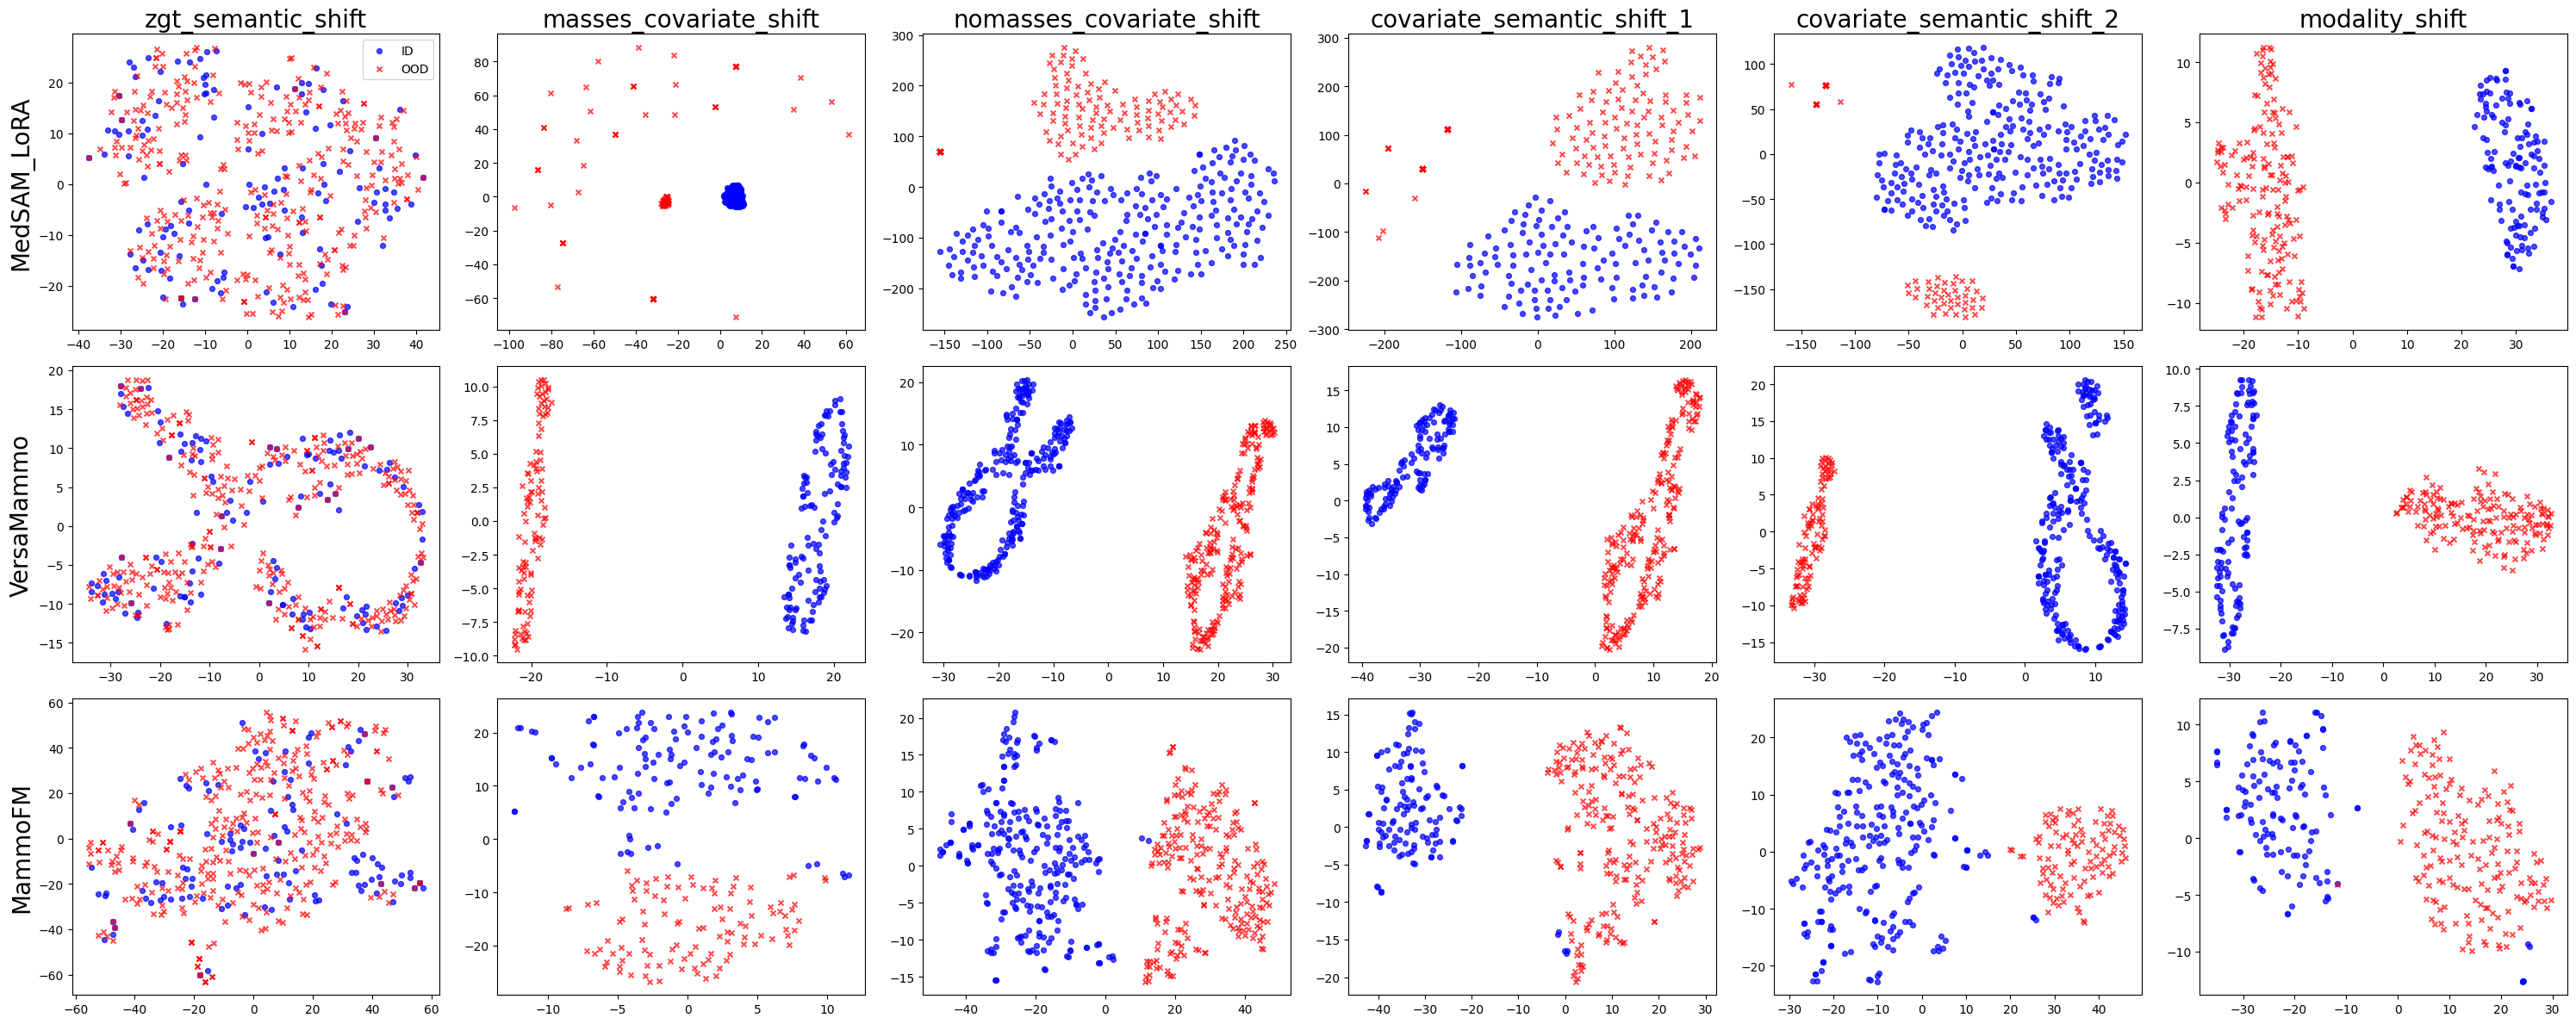

In [7]:
import matplotlib.pyplot as plt
import torch



models = list(ZGT_dict.keys())

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(shift_names),
    figsize=(5 * len(shift_names), 4 * len(models)),
    squeeze=False
)

for row_idx, model in enumerate(models):
    zgt_values = ZGT_dict[model]
    inbreast_values = INbreast_dict[model]
    mamamia_values = Mama_mia_dict[model]

    combinations = {
        "zgt_semantic_shift": zgt_values,
        "masses_covariate_shift": [zgt_values[0], inbreast_values[0]],
        "nomasses_covariate_shift": [zgt_values[1], inbreast_values[1]],
        "covariate_semantic_shift_1": [zgt_values[0], inbreast_values[1]],
        "covariate_semantic_shift_2": [zgt_values[1], inbreast_values[0]],
        "modality_shift": [zgt_values[0], mamamia_values[0]]
    }

    for col_idx, shift_name in enumerate(shift_names):
        v = combinations[shift_name]
        ax = axes[row_idx, col_idx]

        Z_id = torch.load(v[0])

        N_fit = int(Z_id.shape[0] * 0.8)
        Z_id_test = Z_id[N_fit:, :]
        Z_id = Z_id[:N_fit, :]

        Z_ood = torch.load(v[1])

        Y_id = torch.zeros(Z_id.shape[0])
        y_ood = -torch.ones(Z_ood.shape[0])

        X_tsne_id, X_tsne_ood, y_id_plot, y_ood_plot = compute_tsne_id_ood(
            Z_id,
            Y_id,
            Z_ood,
            y_ood=y_ood,
            use_pca=True,
        )

        ax.scatter(
            X_tsne_id[:, 0],
            X_tsne_id[:, 1],
            color="blue",
            alpha=0.7,
            s=18,
            label="ID"
        )

        ax.scatter(
            X_tsne_ood[:, 0],
            X_tsne_ood[:, 1],
            color="red",
            alpha=0.7,
            s=18,
            marker="x",
            label="OOD"
        )

        if row_idx == 0:
            ax.set_title(shift_name, fontsize=20)

        if col_idx == 0:
            ax.set_ylabel(model, fontsize=20)

        if row_idx == 0 and col_idx == 0:
            ax.legend()

plt.tight_layout()
plt.savefig("tsne_grid_models_by_shift.png", dpi=300, bbox_inches="tight")
plt.show()

### Test and evaluate different OOD techniques

In [8]:
from torchmetrics.functional.classification import binary_auroc

def auroc_torchmetrics_from_distances(id_scores, ood_scores, higher_is_ood=True):
    scores = torch.tensor(
        list(id_scores) + list(ood_scores),
        dtype=torch.float64,
    )
    target = torch.tensor(
        [0] * len(id_scores) + [1] * len(ood_scores),
        dtype=torch.long,
    )

    if not higher_is_ood:
        scores = -scores

    # prevent TorchMetrics from interpreting distances as logits
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    return binary_auroc(scores, target).item()

In [9]:
models = list(ZGT_dict.keys())

detector_classes = {
    "Mahalanobis": Mahalanobis,
    "KNN": KNN,
    "GMM": GMM,
}

results = {}

for detector_name, DetectorCls in detector_classes.items():
    results[detector_name] = {}

    for model in models:
        results[detector_name][model] = {}

        zgt_values = ZGT_dict[model]
        inbreast_values = INbreast_dict[model]
        mamamia_values = Mama_mia_dict[model]

        combinations = {
            "zgt_semantic_shift": zgt_values,
            "masses_covariate_shift": [zgt_values[0], inbreast_values[0]],
            "nomasses_covariate_shift": [zgt_values[1], inbreast_values[1]],
            "covariate_semantic_shift_1": [zgt_values[0], inbreast_values[1]],
            "covariate_semantic_shift_2": [zgt_values[1], inbreast_values[0]],
            "modality_shift": [zgt_values[0], mamamia_values[0]]
        }

        for shift, v in combinations.items():
            Z_id = torch.load(v[0])

            N_fit = int(Z_id.shape[0] * 0.8)
            Z_id_test = Z_id[N_fit:, :]
            Z_id_fit = Z_id[:N_fit, :]

            Z_ood = torch.load(v[1])

            Y_id = torch.zeros(Z_id_fit.shape[0], dtype=torch.long)

            det = DetectorCls(encoder=None)
            det.fit_features(Z_id_fit, Y_id)

            scores_id = det.predict_features(Z_id_test)
            scores_ood = det.predict_features(Z_ood)

            y_id = torch.zeros(len(scores_id), dtype=torch.long)
            y_ood = -torch.ones(len(scores_ood), dtype=torch.long)

            scores = torch.cat([
                scores_id.detach().cpu(),
                scores_ood.detach().cpu()
            ])

            y_true = torch.cat([y_id, y_ood])

            auroc = auroc_torchmetrics_from_distances(scores_id, scores_ood)

            metrics = OODMetrics()
            metrics.update(scores, y_true)
            result = metrics.compute()

            results[detector_name][model][shift] = {
                "AUROC": auroc,
                "AUTC": result["AUTC"],
                "FPR95TPR": result["FPR95TPR"],
            }


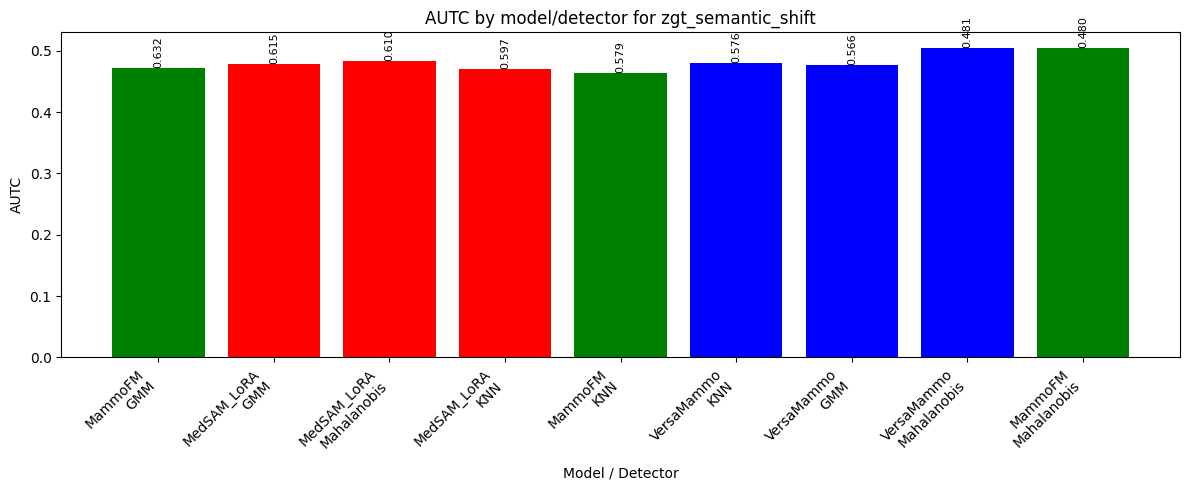

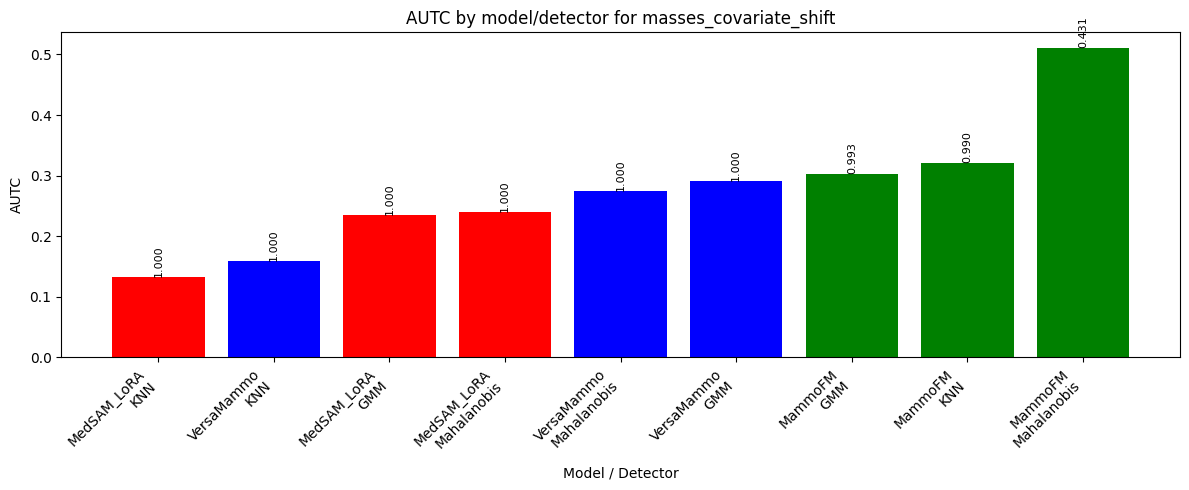

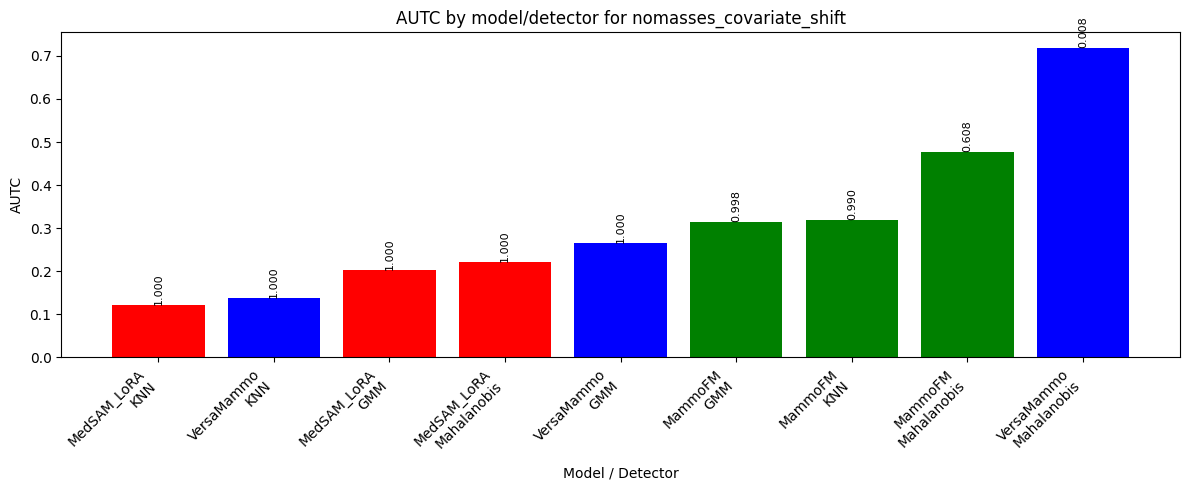

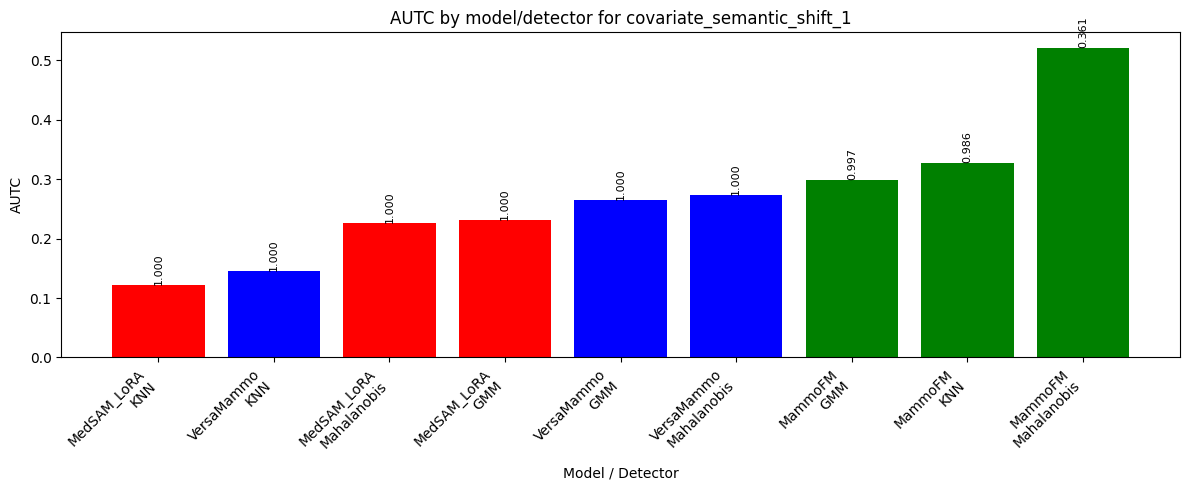

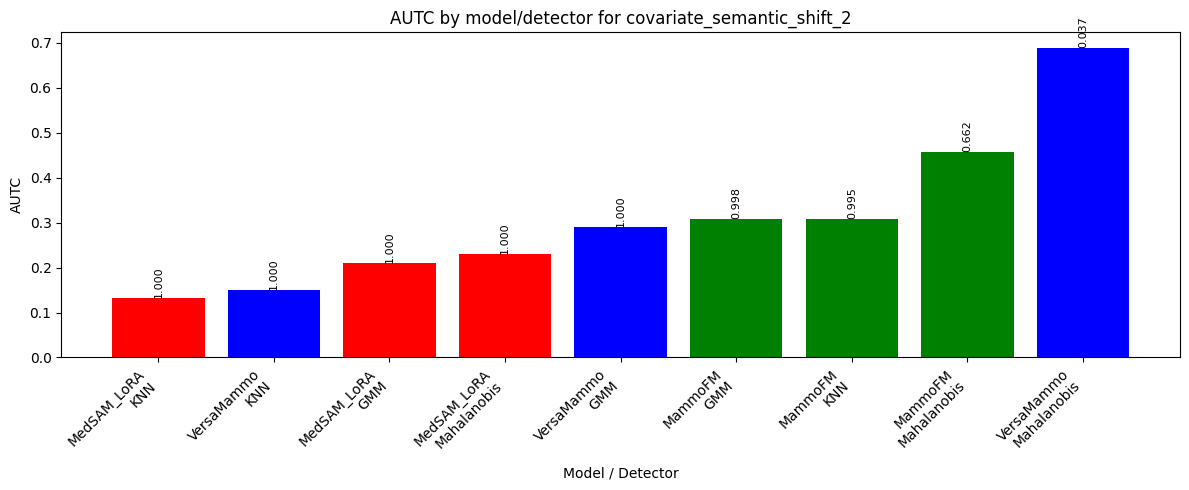

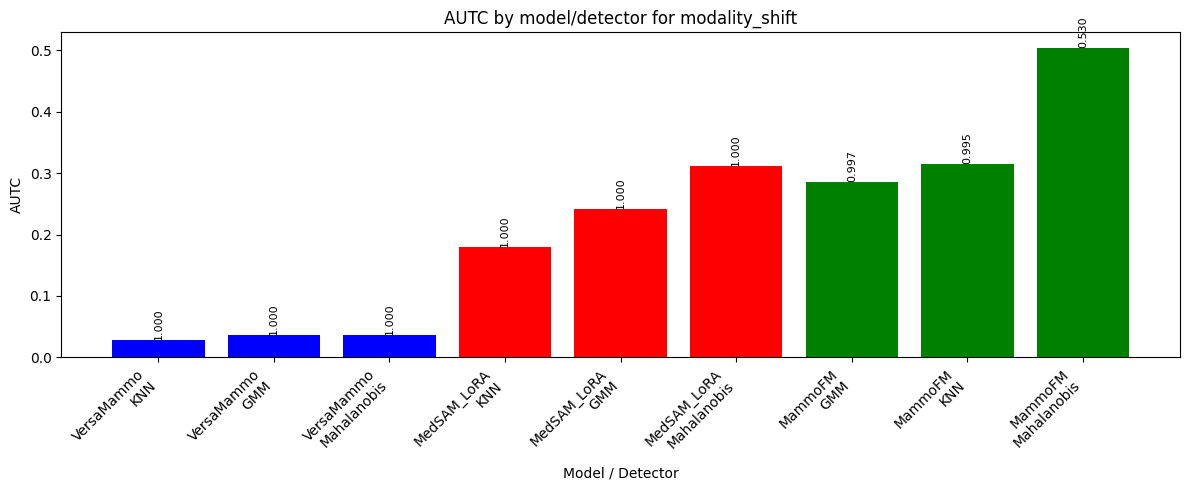

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Flatten nested results dict
rows = []

model_colors = {
    "MedSAM_LoRA": "red",
    "VersaMammo": "blue",
    "MammoFM": "green",
}

for detector_name, detector_results in results.items():
    for model_name, model_results in detector_results.items():
        for shift_name, metrics in model_results.items():
            rows.append({
                "detector": detector_name,
                "model": model_name,
                "shift": shift_name,
                "AUROC": float(metrics["AUROC"]),
                "AUTC": float(metrics["AUTC"]),
                "FPR95TPR": float(metrics["FPR95TPR"]),
            })

df = pd.DataFrame(rows)


for shift_name in df["shift"].unique():
    d = df[df["shift"] == shift_name].copy()

    d["AUROC_round"] = d["AUROC"].round(3)

    d = d.sort_values(
        by=["AUROC_round", "AUTC"],
        ascending=[False, True]
    )

    labels = d["model"] + "\n" + d["detector"]
    colors = [model_colors[m] for m in d["model"]]

    plt.figure(figsize=(12, 5))
    bars = plt.bar(
        labels,
        d["AUTC"],
        color=colors
    )

    plt.title(f"AUTC by model/detector for {shift_name}")
    plt.ylabel("AUTC")
    plt.xlabel("Model / Detector")
    plt.xticks(rotation=45, ha="right")

    for i, (_, row) in enumerate(d.iterrows()):
        plt.text(
            i,
            row["AUTC"],
            f"{row['AUROC']:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

    plt.tight_layout()
    plt.show()

Important caveat

If your actual Mahalanobis score is computed in the original D-dimensional space, then fitting the Gaussian after PCA is only an approximation.

A better projection is:

Fit Gaussian in original feature space.
Sample synthetic points from that Gaussian.
Project both real points and Gaussian samples into PCA or t-SNE.
Plot the samples as the “blob.”


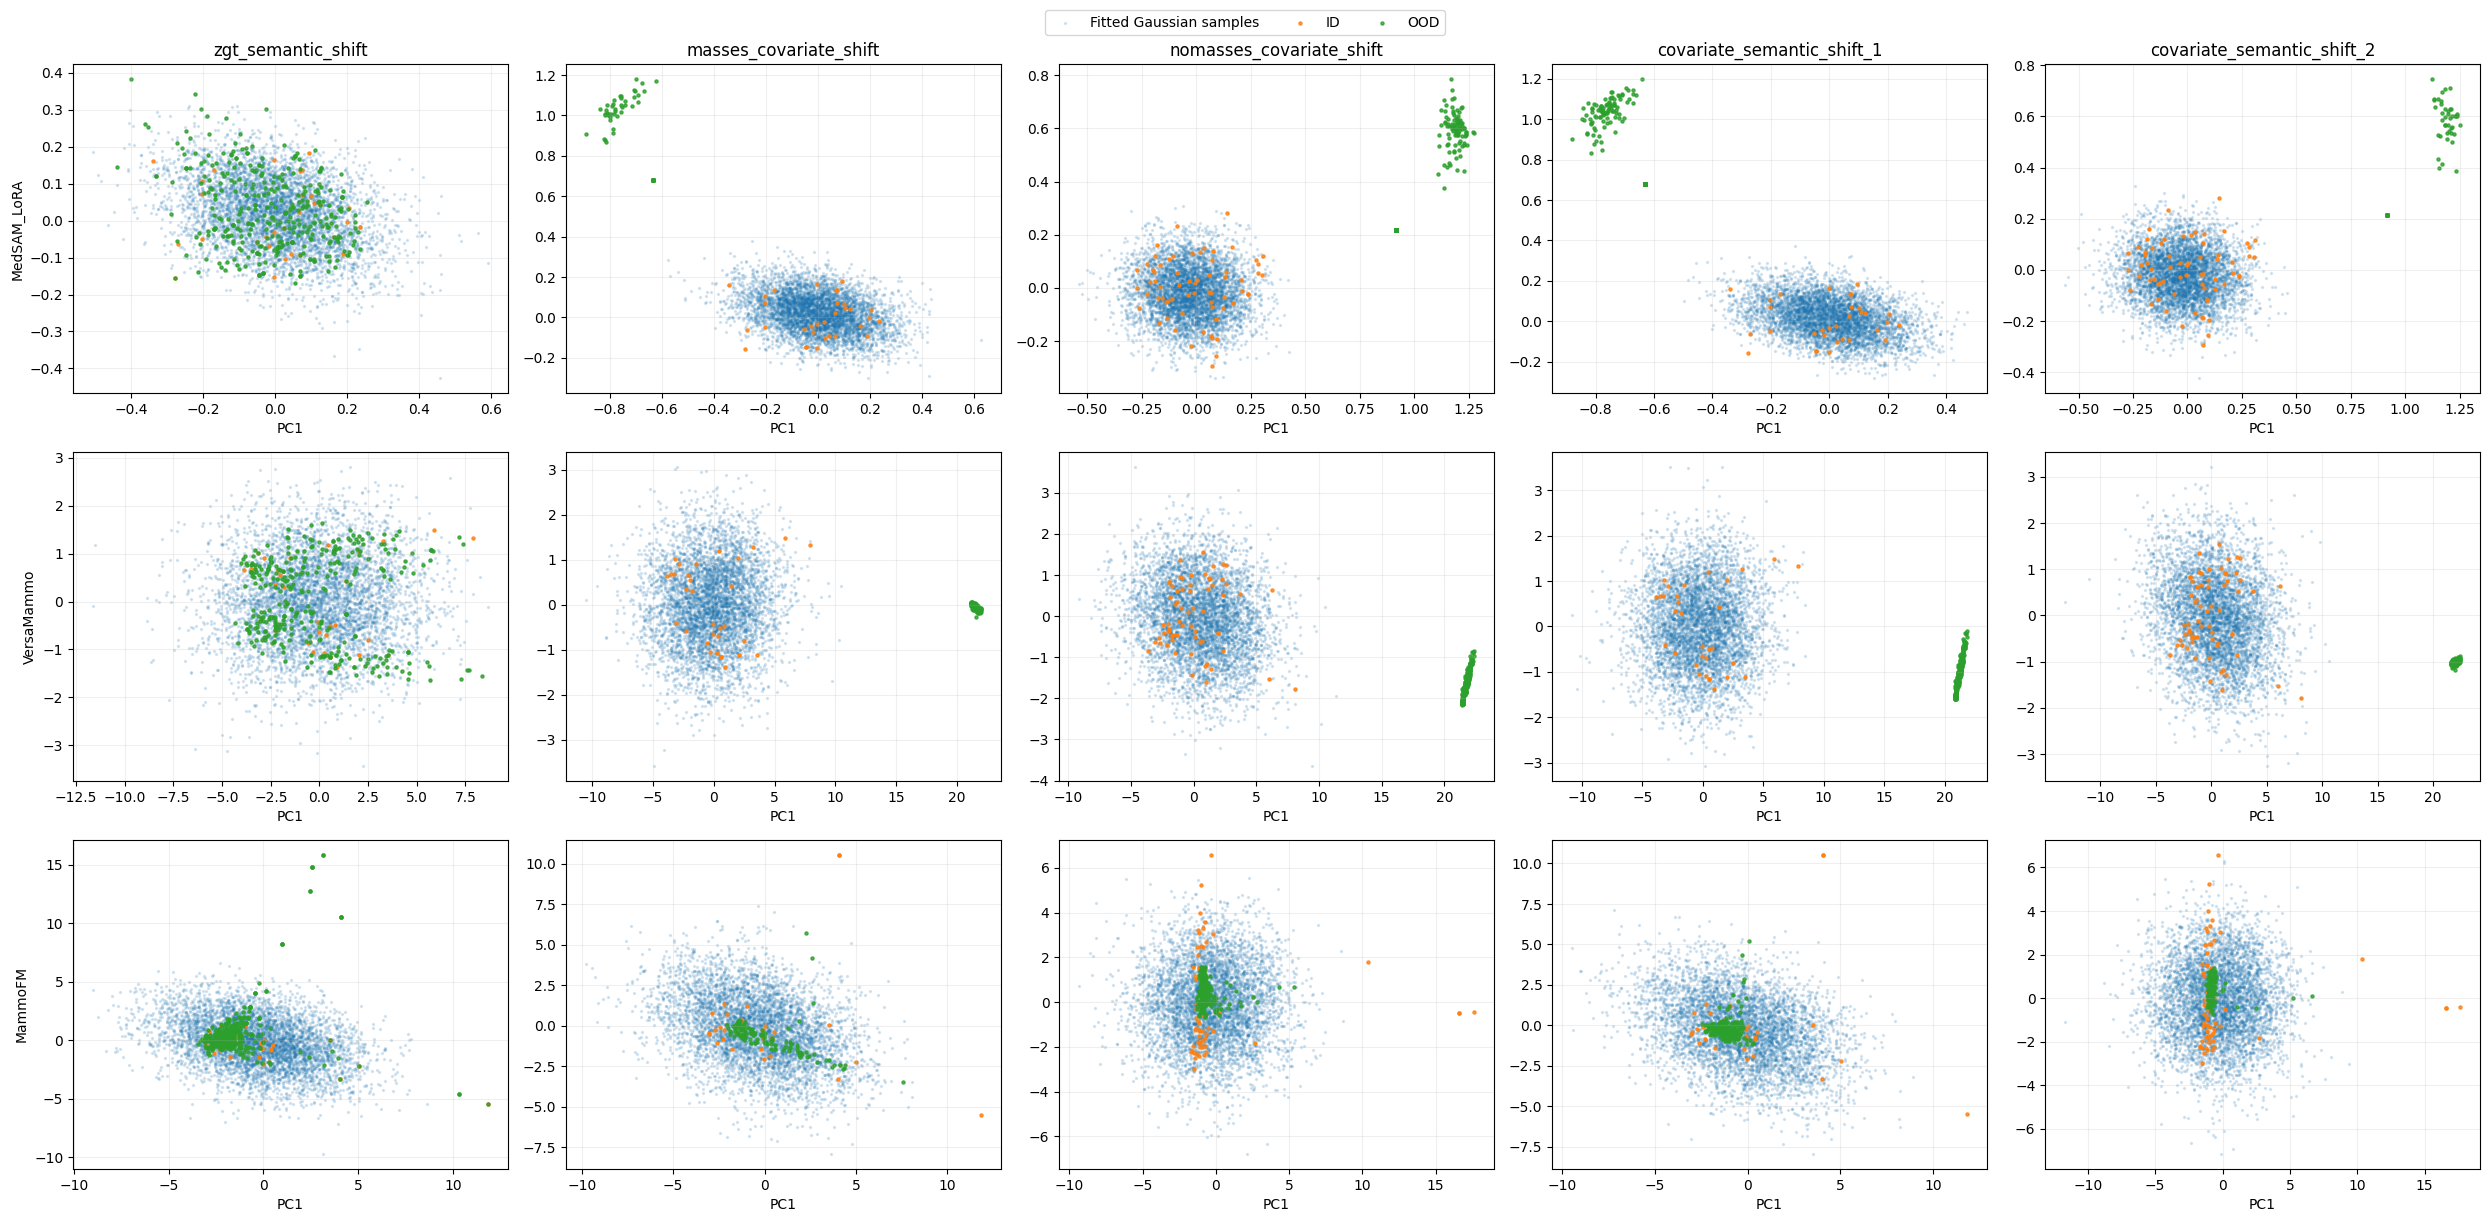

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

shift_combinations_by_model = {}

for model in models:
    zgt_values = ZGT_dict[model]
    inbreast_values = INbreast_dict[model]

    shift_combinations_by_model[model] = {
        "zgt_semantic_shift": zgt_values,
        "masses_covariate_shift": [zgt_values[0], inbreast_values[0]],
        "nomasses_covariate_shift": [zgt_values[1], inbreast_values[1]],
        "covariate_semantic_shift_1": [zgt_values[0], inbreast_values[1]],
        "covariate_semantic_shift_2": [zgt_values[1], inbreast_values[0]],
    }
    
models = list(ZGT_dict.keys())
shifts = list(next(iter(shift_combinations_by_model.values())).keys())

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(shifts),
    figsize=(5 * len(shifts), 4 * len(models)),
    squeeze=False
)


for row_idx, model in enumerate(models):
    for col_idx, shift_name in enumerate(shifts):
        ax = axes[row_idx, col_idx]

        v = shift_combinations_by_model[model][shift_name]

        Z_id = torch.load(v[0]).detach().cpu().numpy()
        Z_ood = torch.load(v[1]).detach().cpu().numpy()

        # optional: same 80/20 split as detector fitting
        N_fit = int(Z_id.shape[0] * 0.8)
        Z_id_fit = Z_id[:N_fit]
        Z_id_test = Z_id[N_fit:]

        mu = Z_id_fit.mean(axis=0)
        cov = np.cov(Z_id_fit.T)

        X_gauss = np.random.multivariate_normal(
            mu,
            cov,
            size=5000
        )

        pca = PCA(n_components=2)
        X2_id = pca.fit_transform(Z_id_test)
        X2_ood = pca.transform(Z_ood)
        X2_gauss = pca.transform(X_gauss)

        ax.scatter(
            X2_gauss[:, 0],
            X2_gauss[:, 1],
            s=2,
            alpha=0.15,
            label="Fitted Gaussian samples"
        )
        ax.scatter(
            X2_id[:, 0],
            X2_id[:, 1],
            s=5,
            alpha=0.8,
            label="ID"
        )
        ax.scatter(
            X2_ood[:, 0],
            X2_ood[:, 1],
            s=5,
            alpha=0.8,
            label="OOD"
        )

        if row_idx == 0:
            ax.set_title(shift_name)

        if col_idx == 0:
            ax.set_ylabel(model)

        ax.set_xlabel("PC1")
        ax.grid(alpha=0.2)

# one shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()
plt.show()

This is misleading because it effectively shows separation in only 2 (PCA) dimensions. There is no way of knowing if this separation acutally holds for the entire feature space, where the ID and OOD reside.


Let's have a look at histograms of scores between the two methods: Mahalanobis and KNN and see the kind of separability they achieve:

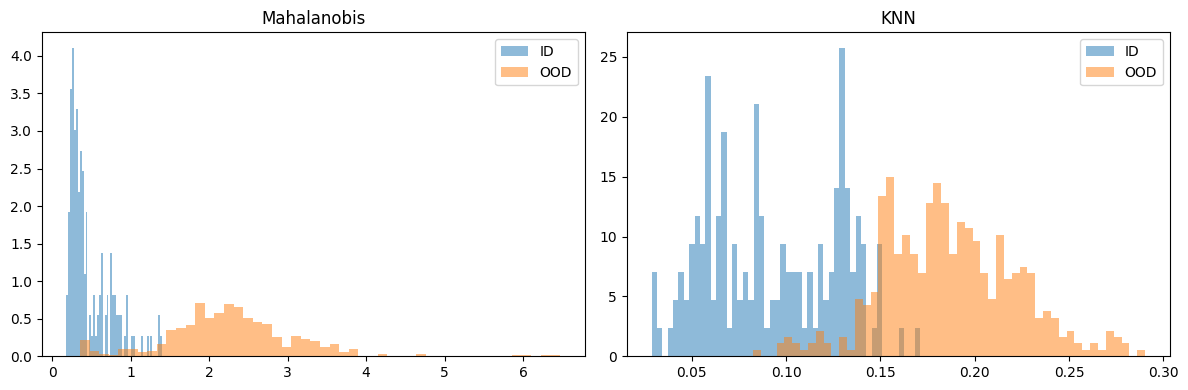

In [105]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mahalanobis
axes[0].hist(scores_id_mds, bins=50, density=True, alpha=0.5, label="ID")
axes[0].hist(scores_ood_mds, bins=50, density=True, alpha=0.5, label="OOD")
axes[0].set_title("Mahalanobis")
axes[0].legend()

# KNN
axes[1].hist(scores_id_knn, bins=50, density=True, alpha=0.5, label="ID")
axes[1].hist(scores_ood_knn, bins=50, density=True, alpha=0.5, label="OOD")
axes[1].set_title("KNN")
axes[1].legend()

# # KNN
# axes[2].hist(scores_id_gmm, bins=50, density=True, alpha=0.5, label="ID")
# axes[2].hist(scores_ood_gmm, bins=50, density=True, alpha=0.5, label="OOD")
# axes[2].set_title("GMM")
# axes[2].legend()

plt.tight_layout()
plt.show()

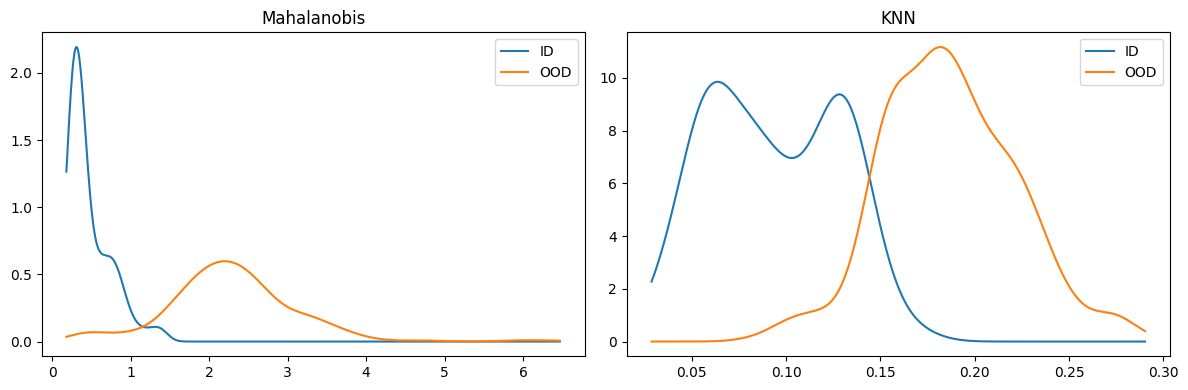

In [108]:
from scipy.stats import gaussian_kde

def plot_kde(ax, id_scores, ood_scores, title):
    x = np.linspace(
        min(id_scores.min(), ood_scores.min()),
        max(id_scores.max(), ood_scores.max()),
        1000
    )

    ax.plot(x, gaussian_kde(id_scores)(x), label="ID")
    ax.plot(x, gaussian_kde(ood_scores)(x), label="OOD")
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_kde(axes[0], scores_id_mds, scores_ood_mds, "Mahalanobis")
plot_kde(axes[1], scores_id_knn, scores_ood_knn, "KNN")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1162/1351945007.py:4: RuntimeWarning: invalid value encountered in log10
  np.log10(scores_id_mds + 1e-8),
/tmp/ipykernel_1162/1351945007.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log10(scores_id_mds + 1e-8),
/tmp/ipykernel_1162/1351945007.py:11: RuntimeWarning: invalid value encountered in log10
  np.log10(scores_ood_mds + 1e-8),
/tmp/ipykernel_1162/1351945007.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log10(scores_ood_mds + 1e-8),


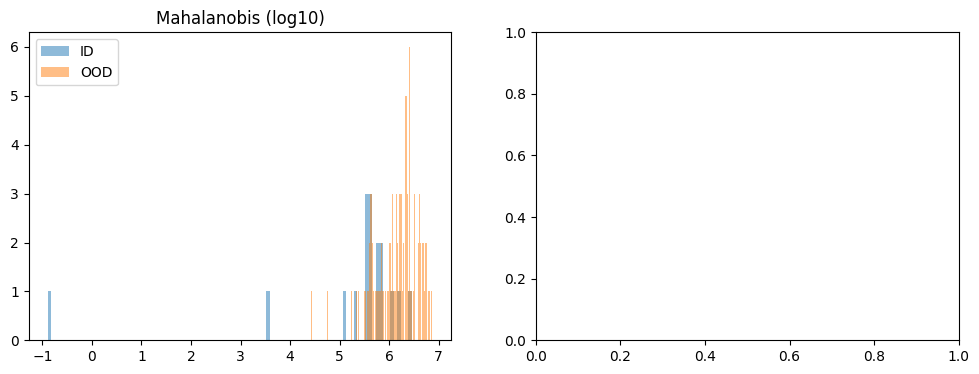

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(
    np.log10(scores_id_mds + 1e-8),
    bins=100,
    alpha=0.5,
    label="ID"
)

axes[0].hist(
    np.log10(scores_ood_mds + 1e-8),
    bins=100,
    alpha=0.5,
    label="OOD"
)

axes[0].set_title("Mahalanobis (log10)")
axes[0].legend()

/tmp/ipykernel_1162/3752635083.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


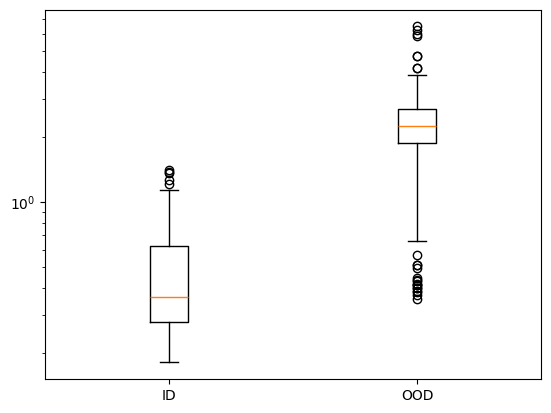

In [106]:
plt.boxplot(
    [scores_id_mds, scores_ood_mds],
    labels=["ID","OOD"]
)
plt.yscale("log")

/tmp/ipykernel_1162/2998457077.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


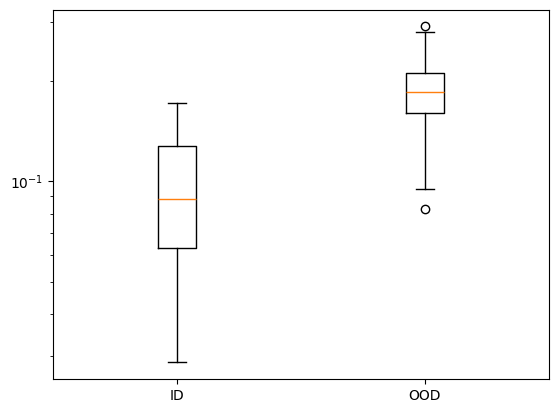

In [107]:
plt.boxplot(
    [scores_id_knn, scores_ood_knn],
    labels=["ID","OOD"]
)
plt.yscale("log")

In [90]:
print(f"scores id percentiles: {np.percentile(scores_id_mds, [1,5,25,50,75,95,99])}")
print(f"scores ood percentiles: {np.percentile(scores_ood_mds, [1,5,25,50,75,95,99])}")

scores id percentiles: [-433231.215      -262848.878125    -84845.53125     -16633.11132812
   60423.546875    202978.478125    303046.35875   ]
scores ood percentiles: [-2301447.42375    -1180023.125       -279326.6015625    -31009.91503906
   218656.3671875   1166019.125       1895127.90625   ]


In [91]:
print(f"scores id percentiles: {np.percentile(scores_id_knn, [1,5,25,50,75,95,99])}")
print(f"scores ood percentiles: {np.percentile(scores_ood_knn, [1,5,25,50,75,95,99])}")

scores id percentiles: [10.94351147 12.50198917 15.90094852 18.51740265 21.53082657 25.92744751
 26.23451546]
scores ood percentiles: [22.06542353 24.46816254 28.36011505 31.02044964 33.46492672 36.68915329
 39.1756525 ]
